In [1]:
import pandas as pd
import pickle
# from rf import RandomForestRegressorBC
from gru import GRU
import os
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(palette="colorblind", style="whitegrid")

In [2]:

##########################################################################################################
# USER INPUT
##########################################################################################################
INPUT_DIR = "/store_new/mch/msrad/radar/radar_database_v2/rf_input_data/"
# OUTPUT_DIR = "/scratch/mch/wolfensb/rainforest_semester_project/saved_models/"
COLS_TO_USE = [
    "RADAR",
    "HEIGHT",
    "ISO0_HEIGHT",
    "ZH_mean",
    "ZV_mean",
    "KDP_mean",
    "RHOHV_mean",
    "SW_mean",
    "AH_mean",
    "VISIB_mean",
] # Which features to use (see rainforest paper for justification)
N_SPLITS = 4 # K-fold split
SUBSET = 1  # Use a subset of data for faster example running (max = 1.0)
##########################################################################################################


In [10]:
# same random subset function as used in gru
def random_group_subset(groups, subset_percent, shuffle=True, random_state=None):
    """
    Randomly selects a subset of groups.

    Parameters
    ----------
    groups : array-like of shape (n_samples,)
        Group labels for each row.
    subset_percent : float
        Percentage of groups to select (between 0 and 1).
    shuffle : bool
        Whether to shuffle group order.
    random_state : int or None
        Random seed.

    Returns
    -------
    subset_mask : ndarray of shape (n_samples,)
        Boolean mask indicating which rows belong to the selected groups.
    """
    rng = np.random.default_rng(random_state)

    unique_groups = np.unique(groups)

    if shuffle:
        rng.shuffle(unique_groups)

    n_subset = int(len(unique_groups) * subset_percent)
    selected_groups = rng.choice(unique_groups, size=n_subset, replace=False)

    subset_mask = np.isin(groups, selected_groups)
    # In subset_mask we lose the original ordering of the selected groups
    # so we also need to reorder selected groups
    return sorted(selected_groups), subset_mask


In [ ]:
# --- Load data ------------------------------------------------------------------

radar = pd.read_parquet(os.path.join(INPUT_DIR, "radar_x0y0.parquet"), engine="pyarrow")
gauge = pd.read_parquet(os.path.join(INPUT_DIR, "gauge.parquet"))
groups = pickle.load(open(os.path.join(INPUT_DIR, "grouping_idx_x0y0.p"), "rb"))

features = radar[COLS_TO_USE]
vertgroups = groups["grp_vertical"]
targets = gauge["RRE150Z0"]  # must be indexed by vertgroup ids for loc[] usage below

# Subset data for faster example running
selected_groups, subset_mask = random_group_subset(vertgroups, SUBSET, random_state=42)
features = features.loc[subset_mask] # TODO evtl iloc benutzen
vertgroups = vertgroups[subset_mask]
targets = targets.loc[selected_groups]

NameError: name 'random_group_subset' is not defined

## groups (vertgroups)
the dataformat is a dictionary but we only need the values for the key 'grp_vertical' - this index maps a radar observation to a specific gauge measurement (at a specific time). It has therefore the **same order as radar** and we have to be careful to not mix it up.

In order to aggregate the data to the ground you have to use the dictionary contained in grouping_idx_x0y0.p, where the key “grp_vertical” contains a unique digit for every vertical column, the number of unique digits is equal to the number of observations at the ground (gauge.parquet file)

In [12]:
# maps a radar observation to a specific gauge measurement (at a specific time)
print(groups.keys())
print(f'Nr of radar observations / nr of entries in groups: {len(groups["grp_vertical"])}' ) # same as entries in radars
print(f'Nr of gauge measurements / nr of unique entries in groups: {len(np.unique(groups["grp_vertical"]))}') # same as rows in gauge


dict_keys(['grp_vertical', 'grp_time', 'tstamp_unique', 'native_time_res'])
Nr of radar observations / nr of entries in groups: 98245214
Nr of gauge measurements / nr of unique entries in groups: 10481202


## gauge

See description of fields of gauge and radar [here](https://meteoswiss.github.io/rainforest/reference/db_structure.html) 

! we can see some NaN values sometimes, even for precipitation

In [6]:
gauge = pd.read_parquet(os.path.join(INPUT_DIR, "gauge.parquet"))
print(len(gauge))
display(gauge.head(10))
gauge.index[1]
#TODO: does daniel filter the NaN's somewhere?

10481202


,STATION,TIMESTAMP,TRE200S0,PRESTAS0,URE200S0,RRE150Z0,DKL010Z0,FKL010Z0,RRE150Z0_ADJ,s-tstamp,minutes
0,BUS,1451607000,5.2,980.0,98.1,0.0,0.0,0.0,0.0,BUS1451607000,10.0
1,CHZ,1451607000,4.9,973.3,99.3,0.0,66.0,0.3,0.0,CHZ1451607000,10.0
2,EIN,1451607000,2.8,919.0,100.0,0.0,312.0,0.5,0.0,EIN1451607000,10.0
3,GIH,1451607000,2.6,970.2,99.2,0.0,219.0,1.1,0.0,GIH1451607000,10.0
4,GOE,1451607000,5.3,980.7,97.2,0.0,0.0,0.0,0.0,GOE1451607000,10.0
5,LUZ,1451607000,4.8,971.8,96.0,0.4,58.0,0.7,0.4,LUZ1451607000,10.0
6,ROG,1451607000,3.0,NaN,NaN,0.0,NaN,NaN,NaN,ROG1451607000,10.0
7,RUE,1451607000,5.0,953.4,98.2,0.1,229.0,0.5,0.1,RUE1451607000,10.0
8,SAG,1451607000,3.8,NaN,98.9,0.0,56.0,1.3,0.0,SAG1451607000,10.0
9,SIH,1451607000,NaN,NaN,NaN,0.0,NaN,NaN,NaN,SIH1451607000,10.0


1

In [16]:
print(f'Nr. of different rain gauges: {gauge["STATION"].nunique()}')

per_gauge_avgmeasurements = np.mean(gauge.groupby("STATION").agg(count = ("STATION", "count")).reset_index()["count"])
print(f'Avg nr of measurements per station: {per_gauge_avgmeasurements:.2f}')

Nr. of different rain gauges: 267
Avg nr of measurements per station: 39255.44


[]

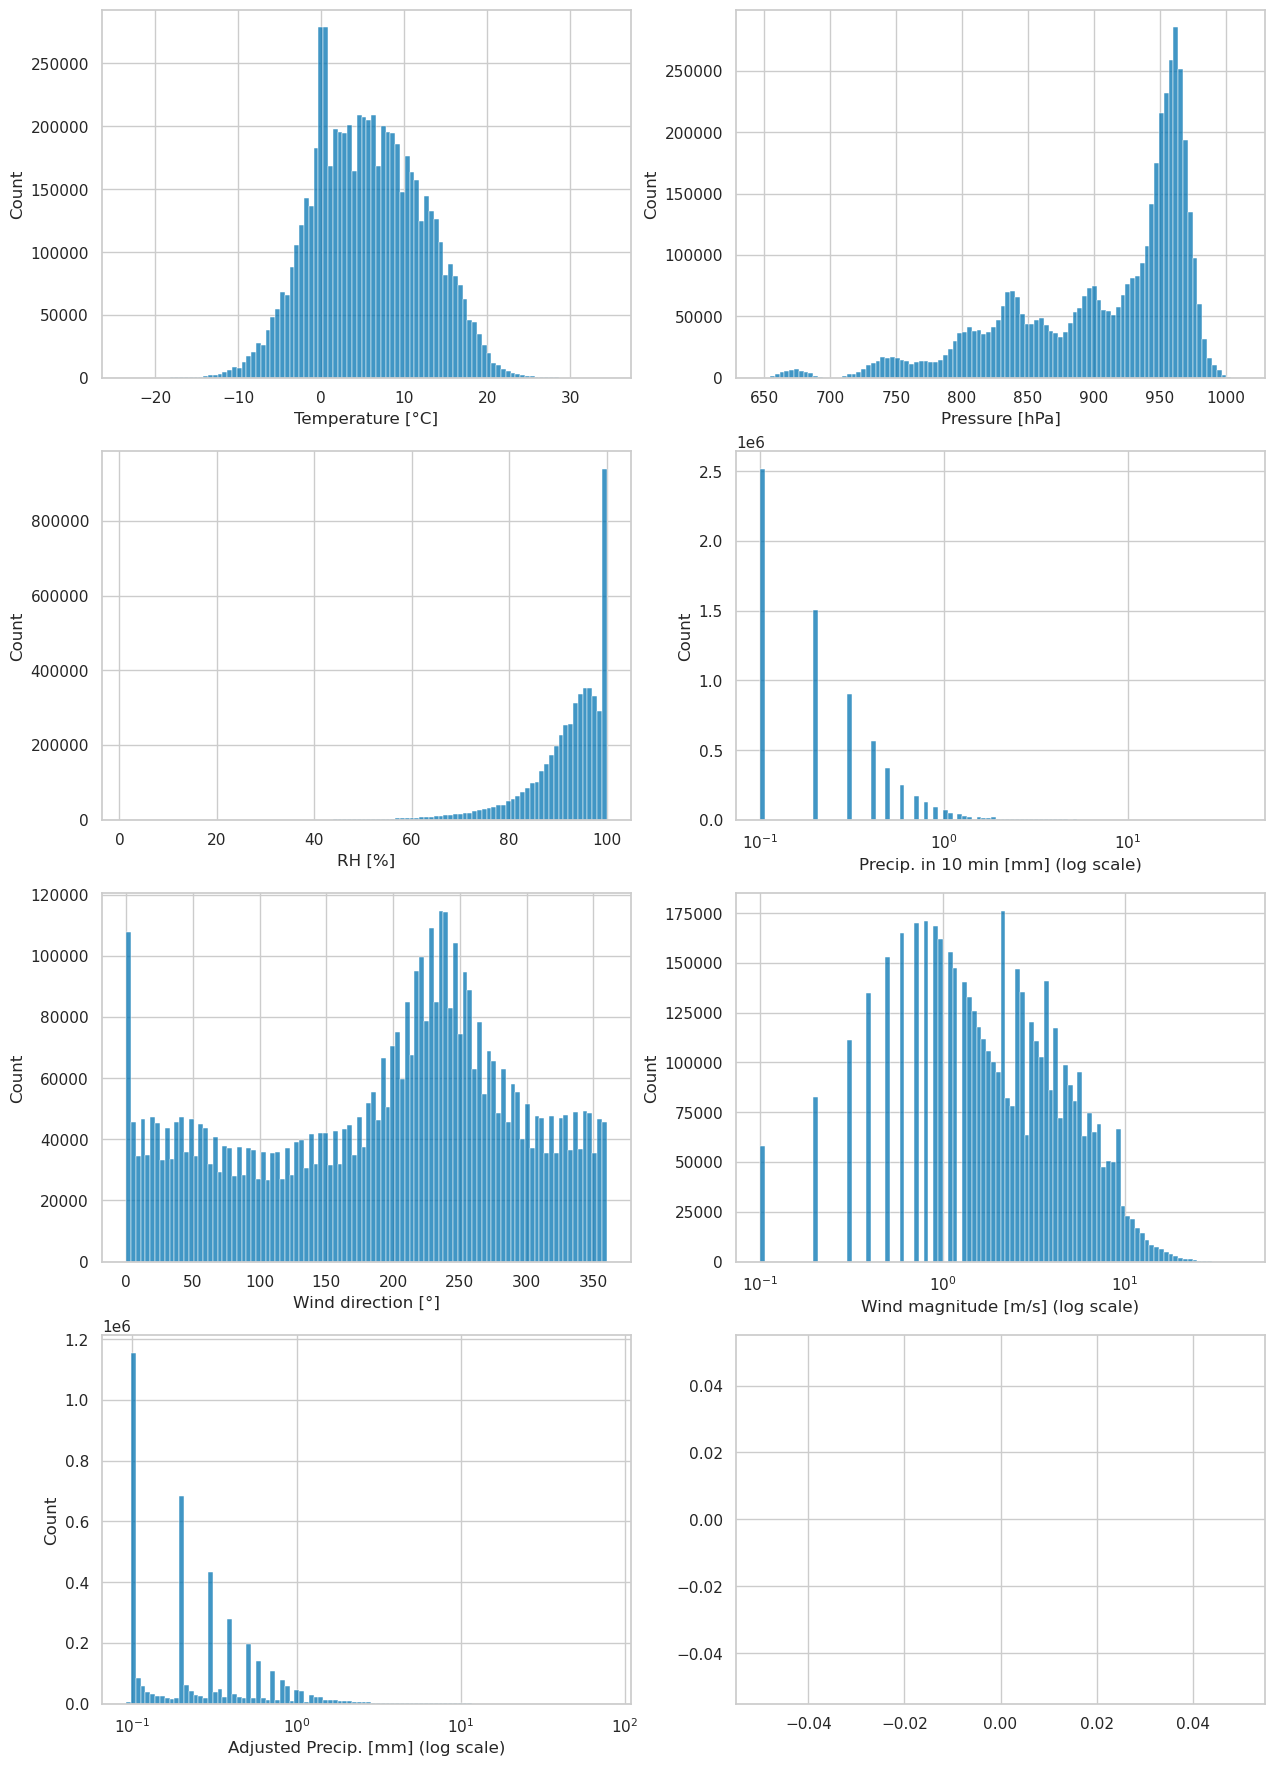

In [ ]:
gauge_codes = ["Temperature [°C]", "Pressure [hPa]", "RH [%]", "Precip. in 10 min [mm]", "Wind direction [°]", "Wind magnitude [m/s]", "Adjusted Precip. [mm]"]

fig, ax = plt.subplots(int(np.ceil(len(gauge.columns[2:-2])/2)),2, figsize=(15, 22))
axes = ax.flatten()
for i, (var, ax) in enumerate(zip(gauge.columns[2:-2], axes)):

    log = False
    if i in [3, 5, 6]:
        log = True
    sns.histplot(data=gauge, x=var, ax=ax, bins=100, log_scale=log)
    ax.set_xlabel(gauge_codes[i] + (" (log scale)" if log else ""))
    
plt.title("Nr of raingauge measurements for changing environmental forcings")    
plt.plot()


KeyboardInterrupt: 

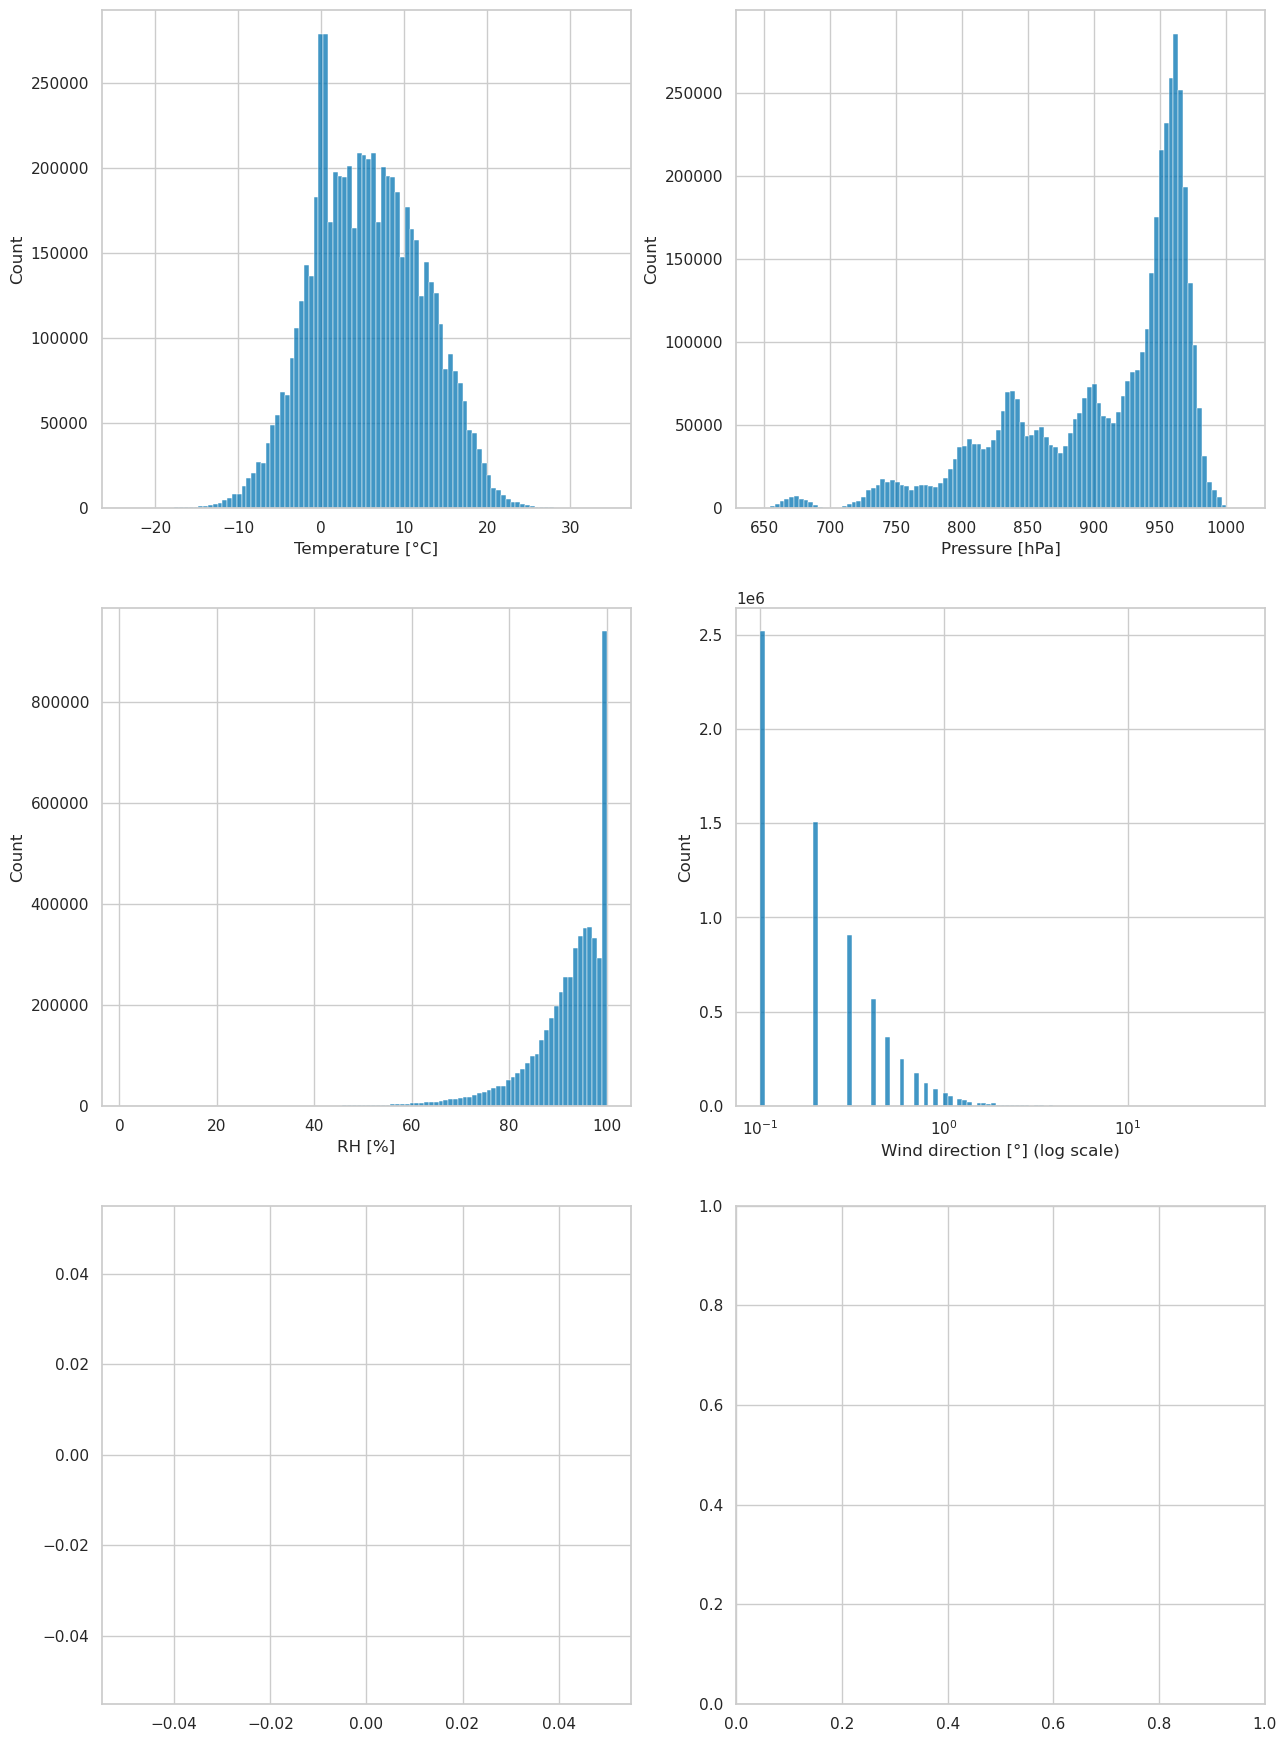

In [ ]:
# precip intensities for different env. forcings
gauge_codes = ["Temperature [°C]", "Pressure [hPa]", "RH [%]", "Wind direction [°]", "Wind magnitude [m/s]"]

fig, ax = plt.subplots(3,2, figsize=(15, 22))
axes = ax.flatten()
for i, (var, ax) in enumerate(zip([col if not "precip" in col else _ for col in gauge.columns[2:-2]], axes)):


    sns.lineplot(data=gauge, x=var, y="RRE150Z0", estimator="mean", ax=ax)
    ax.set_xlabel(gauge_codes[i])
    ax.set_ylabel("Mean precipitation [mm]")
    
plt.title("Mean precipitation for changing environmental forcings")    
plt.plot()

## radar

In [3]:
radar = pd.read_parquet(os.path.join(INPUT_DIR, "radar_x0y0.parquet"), engine="pyarrow")
groups = pickle.load(open(os.path.join(INPUT_DIR, "grouping_idx_x0y0.p"), "rb"))
gauge = pd.read_parquet(os.path.join(INPUT_DIR, "gauge.parquet"))
radar["vertgroup"] = groups["grp_vertical"]

print(len(radar))
display(radar.head(10))


98245214


,TIMESTAMP,STATION,RADAR,SWEEP,NX,NY,HEIGHT,VPR,RADPRECIP,ISO0_HEIGHT,...,NV_mean,TCOUNT,s-tstamp,ID,Name,Y,X,Z,Type,vertgroup
0,1451607000,BUS,A,1,0,0,892.029480,2.167466,NaN,1556.250000,...,-6.471725,3,BUS1451607000,67,Buchs / Aarau,648396,248370,387,SwissMetNet,0
1,1451607000,BUS,A,4,0,0,1967.833984,2.629891,NaN,1556.250000,...,-6.542049,3,BUS1451607000,67,Buchs / Aarau,648396,248370,387,SwissMetNet,0
2,1451607000,CHZ,A,1,0,0,905.715820,2.169928,NaN,1635.937500,...,-15.792347,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
3,1451607000,CHZ,A,2,0,0,1028.433105,2.136923,NaN,1635.937500,...,-15.778623,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
4,1451607000,CHZ,A,3,0,0,1151.139526,1.921290,NaN,1635.937500,...,-15.792347,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
5,1451607000,CHZ,A,4,0,0,1273.821655,1.527064,NaN,1635.937500,...,-15.793533,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
6,1451607000,CHZ,A,5,0,0,1459.179199,1.071767,NaN,1635.661743,...,-15.782661,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
7,1451607000,CHZ,A,6,0,0,1663.955688,1.561178,NaN,1635.661743,...,-15.767613,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
8,1451607000,CHZ,A,7,0,0,1851.854980,2.359750,NaN,1637.500000,...,-15.869020,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1
9,1451607000,CHZ,A,8,0,0,2052.500488,2.782081,NaN,1637.500000,...,-15.924747,3,CHZ1451607000,162,Cham,677758,226878,442,SwissMetNet,1


In [ ]:
print(f'average of {len(radar)/len(gauge):.2f} radar measurements per precipitation measurement')

Therefore we have one average 9.37 radar measurements per precipitation measurement


#### Analysis of radar sequences

[]

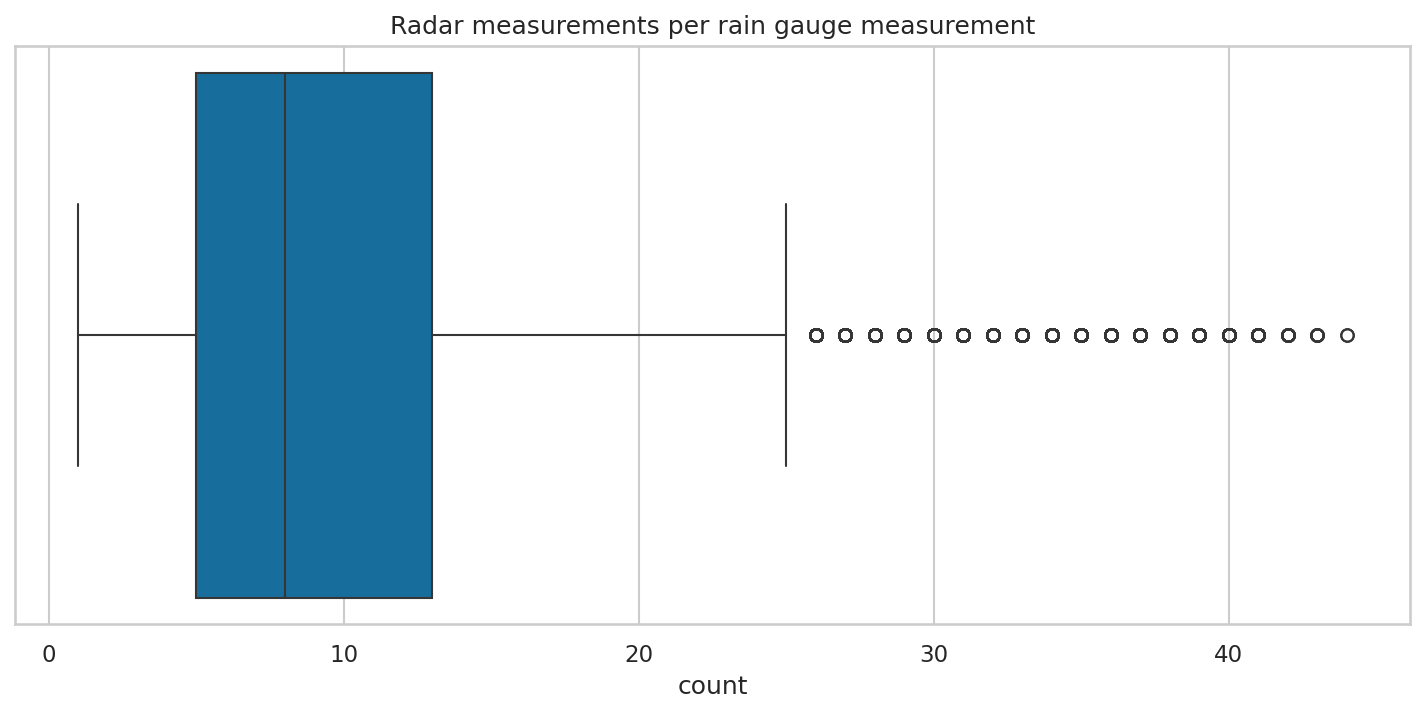

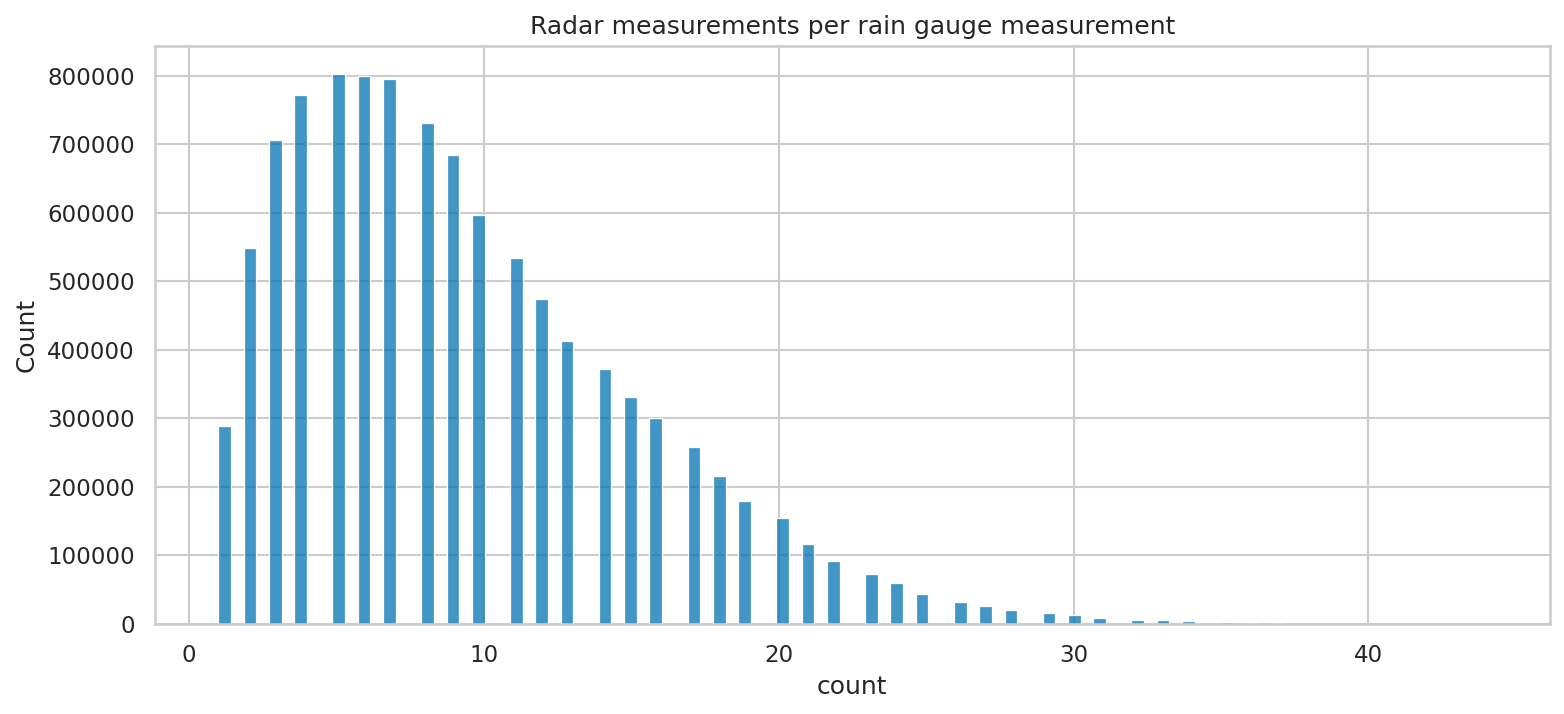

In [ ]:
# avg, min, max radar observations per sequence

sequences = radar.groupby("vertgroup").agg(count=("STATION", "count")).reset_index()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
plt.title("Radar measurements per rain gauge measurement")
sns.boxplot(sequences, x="count")
plt.plot()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
plt.title("Radar measurements per rain gauge measurement")
sns.histplot(sequences, x="count", bins=100)
plt.plot()

##### Time in between sequences

In [4]:
sequences = radar.sort_values("TIMESTAMP").groupby("vertgroup").agg(timestamp=("TIMESTAMP", "mean")).reset_index()
sequences = pd.concat([sequences, gauge], axis=1)


#time between consecutive measurements in the dataset
timeBetweenSequences = []
for station in sequences["STATION"].unique():
    seq_sorted = sequences[sequences["STATION"] == station].sort_values("timestamp")["timestamp"]
    timeBetweenSequences.extend(seq_sorted.diff().to_list()[1:])
timeBetweenSequences = np.array(timeBetweenSequences)

In [ ]:
# statistics for time in between sequences
timeBetweenSequencesMins = timeBetweenSequences/60
timeBetweenSequencesMins.min(), timeBetweenSequencesMins.max(), np.median(timeBetweenSequencesMins), timeBetweenSequencesMins.mean()

(np.float64(10.0),
 np.float64(549070.0),
 np.float64(10.0),
 np.float64(115.32152522651843))

Text(0.5, 1.0, 'Histplot of the time between sequeces')

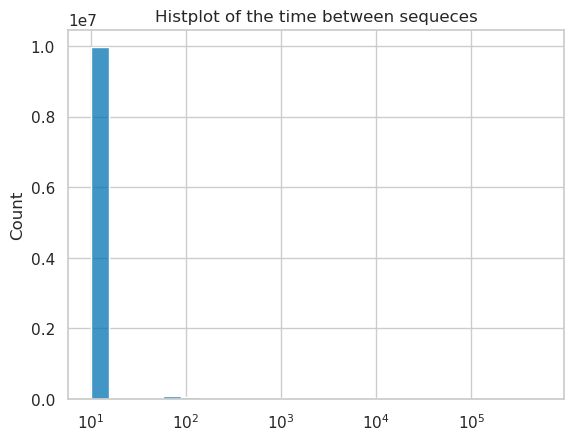

In [17]:
sns.histplot(timeBetweenSequencesMins, log_scale=True)
plt.title("Histplot of the time between sequeces")

Nr of consecutive sequences: 9,965,801 (10 min difference)


Text(0.5, 1.0, 'Lineplot of time in between sequences, without distance of 10min')

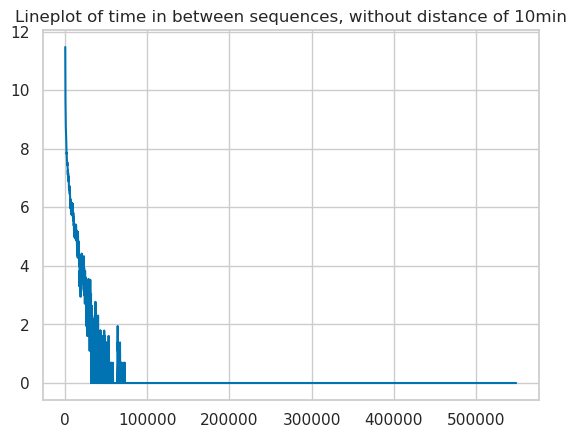

In [18]:
unique = np.unique_counts(np.sort(timeBetweenSequencesMins))

print(f'Nr of consecutive sequences: {unique.counts[0]:,} (10 min difference)')

sns.lineplot(x = unique.values[1:], y=np.log(unique.counts[1:]))
plt.title("Lineplot of time in between sequences, without distance of 10min")


## Analysis of GRU input data
of daniels work

In [18]:
# TODO: we need test data

In [15]:
# daniels prepare for GRU function
def prepare_for_gru(radar_db):
    radar_sub = pd.get_dummies(radar_db, columns=["RADAR"]) # one hot for radar
    dummies = [col for col in radar_sub.columns if col.startswith("RADAR_")]
    numeric = radar_sub.columns.difference(dummies) # all the other features but radar
    scaler = StandardScaler()
    radar_sub[numeric] = scaler.fit_transform(radar_sub[numeric])
    radar_sub = radar_sub.astype(
        {col: "int8" for col in radar_sub.select_dtypes("boolean").columns}
    )
    return radar_sub

In [ ]:
features_gru = prepare_for_gru(features)
gru_model = GRU(input_dim=features_gru.shape[1])


In [27]:
np.unique(targets.index)

array([       3,        5,       10, ..., 10481164, 10481194, 10481197],
      shape=(1048120,))